<a href="https://colab.research.google.com/github/renatacr1607/Circuitos/blob/master/1_Aula_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ana Carolina Braz de Oliveira - 202220601
# Renata Cândido Rodrigues - 202220065


# =============================================================================
# CHUNK 1: GERAÇÃO DO DATASET SINTÉTICO
# =============================================================================

# Importamos a função make_classification, que cria datasets artificiais
# Isso é útil para aulas porque controlamos exatamente as características dos dados
from sklearn.datasets import make_classification
import numpy as np

# Fixamos a semente aleatória para que todos na turma obtenham os mesmos resultados
# Sem isso, cada execução geraria dados diferentes
np.random.seed(42)

# Criamos o dataset com as seguintes características:
# - 500 amostras: pequeno o suficiente para treinar rápido
# - 50 features (colunas de entrada): simula um problema de alta dimensionalidade
# - Apenas 5 features são realmente informativas (carregam o "sinal" útil)
# - 5 features são redundantes (combinações lineares das informativas)
# - As 40 restantes são puro ruído (não ajudam na classificação)
# - 2 classes (classificação binária): ex. "sim" ou "não"
X, y = make_classification(
    n_samples=1000,           # número total de amostras
    n_features=50,           # número total de features (colunas)
    n_informative=20,         # features que realmente importam
    n_redundant=5,           # features que são cópias "disfarçadas" das informativas
    n_classes=2,             # problema binário (duas classes)
    random_state=42          # semente para reprodutibilidade
)

# Vamos verificar o formato dos dados gerados
print(f"Formato das entradas (X): {X.shape}")   # Esperado: (500, 50)
print(f"Formato das saídas (y):  {y.shape}")     # Esperado: (500,)
print(f"Classes existentes:      {np.unique(y)}") # Esperado: [0, 1]
print(f"\nExemplo de uma amostra (primeiras 10 features):")
print(f"  X[0][:10] = {np.round(X[0][:10], 3)}")
print(f"  Classe:     {y[0]}")


Formato das entradas (X): (1000, 50)
Formato das saídas (y):  (1000,)
Classes existentes:      [0 1]

Exemplo de uma amostra (primeiras 10 features):
  X[0][:10] = [-1.356 -0.627  2.002 -4.04   3.184 -0.291 -0.451 -0.329  2.713 -0.862]
  Classe:     0


In [ ]:
# =============================================================================
# CHUNK 2: DIVISÃO DOS DADOS E NORMALIZAÇÃO (VERSÃO SEM PCA)
# =============================================================================

# Importamos as ferramentas necessárias:
# - train_test_split: divide os dados em treino e teste
# - StandardScaler: normaliza os dados (média 0, desvio padrão 1)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividimos os dados em dois grupos:
# - 70% para TREINO: a rede neural aprende com esses dados
# - 30% para TESTE: usamos para avaliar se a rede generalizou bem
# stratify=y garante que ambas as classes (0 e 1) fiquem bem distribuídas nos dois grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
     test_size=0.2,       # 30% dos dados vão para teste
    random_state=42,     # semente para reprodutibilidade
    stratify=y           # mantém a proporção das classes em treino e teste
)

print(f"Dados de treino: {X_train.shape[0]} amostras")  # Esperado: 350
print(f"Dados de teste:  {X_test.shape[0]} amostras")   # Esperado: 150

# NORMALIZAÇÃO (StandardScaler)
# Redes neurais funcionam melhor quando os dados estão na mesma escala.
# O StandardScaler transforma cada feature para ter:
#   - Média = 0
#   - Desvio padrão = 1
#
# IMPORTANTE: fazemos o "fit" APENAS nos dados de treino.
# Depois "transformamos" tanto treino quanto teste com a MESMA escala.
# Isso evita "vazamento de informação" do teste para o treino.
#scaler = StandardScaler()

# Aprende a escala a partir dos dados de treino
#scaler.fit(X_train)

# Aplica a normalização nos dois conjuntos
#X_train_scaled = scaler.transform(X_train)
#X_test_scaled = scaler.transform(X_test)
X_train_scaled = X_train
X_test_scaled = X_test
# Verificamos que a normalização funcionou
# A média deve ser próxima de 0 e o desvio padrão próximo de 1 no treino
print(f"\nApós normalização (dados de treino):")
print(f"  Média das features (primeiras 5):  {np.round(X_train_scaled.mean(axis=0)[:5], 4)}")
print(f"  Desvio padrão (primeiras 5):       {np.round(X_train_scaled.std(axis=0)[:5], 4)}")
print(f"\nDimensão mantida: {X_train_scaled.shape[1]} features (todas as 50)")



Dados de treino: 800 amostras
Dados de teste:  200 amostras

Após normalização (dados de treino):
  Média das features (primeiras 5):  [ 0.0132  0.0107 -0.0058 -0.5418  1.2926]
  Desvio padrão (primeiras 5):       [1.0295 1.0357 0.9899 2.5826 6.0287]

Dimensão mantida: 50 features (todas as 50)


In [ ]:
# =============================================================================
# CHUNK 3: REDE NEURAL SEM PCA
# =============================================================================

# Usamos o MLPClassifier do scikit-learn (Multi-Layer Perceptron)
# É uma rede neural simples, ideal para aulas por não exigir frameworks pesados
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Construímos a rede neural com a seguinte arquitetura:
# - Camada de entrada: 50 neurônios (um por feature — todas as 50, incluindo ruído)
# - 1ª camada oculta: 32 neurônios
# - 2ª camada oculta: 16 neurônios
# - Camada de saída: 2 neurônios (uma por classe)
#
# Parâmetros importantes:
# - activation='relu': função de ativação mais usada em redes modernas
# - max_iter=500: número máximo de épocas (passadas completas pelos dados)
# - random_state=42: garante reprodutibilidade
# - early_stopping=True: para o treino se a rede parar de melhorar
#   (isso evita overfitting e economiza tempo)
# - validation_fraction=0.15: separa 15% do treino para monitorar o desempenho
modelo_sem_pca = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),   # duas camadas ocultas: 32 e 16 neurônios
    activation='relu',              # função de ativação ReLU
    max_iter=500,                   # máximo de 500 épocas
    random_state=42,                # semente para reprodutibilidade
    early_stopping=True,            # para quando parar de melhorar
    validation_fraction=0.15        # 15% do treino usado como validação interna
)

# Treinamos a rede com TODAS as 50 features (incluindo as ruidosas)
# A rede precisa "descobrir sozinha" quais features importam — tarefa difícil!
print("Treinando rede neural SEM PCA (50 features)...")
modelo_sem_pca.fit(X_train_scaled, y_train)
print(f"Treino concluído em {modelo_sem_pca.n_iter_} épocas.")

# Fazemos as previsões no conjunto de teste
y_pred_sem_pca = modelo_sem_pca.predict(X_test_scaled)

# Avaliamos o desempenho
acuracia_sem_pca = accuracy_score(y_test, y_pred_sem_pca)

print(f"\n{'='*50}")
print(f"RESULTADOS SEM PCA")
print(f"{'='*50}")
print(f"Acurácia no teste: {acuracia_sem_pca:.4f} ({acuracia_sem_pca*100:.2f}%)")
print(f"\nRelatório detalhado:")
print(classification_report(y_test, y_pred_sem_pca, target_names=["Classe 0", "Classe 1"]))

# Guardamos o resultado para comparar depois com a versão COM PCA
print(">> Resultado salvo para comparação futura.")

Treinando rede neural SEM PCA (50 features)...
Treino concluído em 53 épocas.

RESULTADOS SEM PCA
Acurácia no teste: 0.9000 (90.00%)

Relatório detalhado:
              precision    recall  f1-score   support

    Classe 0       0.88      0.92      0.90       100
    Classe 1       0.92      0.88      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200

>> Resultado salvo para comparação futura.


Variância explicada acumulada por número de componentes:
--------------------------------------------------
   1 componentes → 26.9% da informação
   2 componentes → 42.6% da informação
   3 componentes → 57.0% da informação
   5 componentes → 71.0% da informação
   8 componentes → 79.1% da informação
  10 componentes → 83.0% da informação
  15 componentes → 90.2% da informação
  20 componentes → 94.3% da informação
  30 componentes → 97.0% da informação
  50 componentes → 100.0% da informação


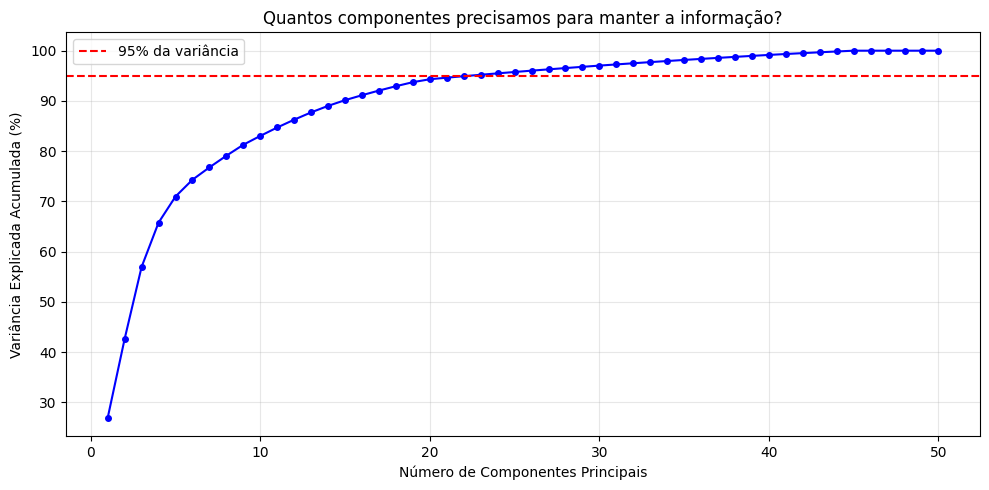


Gráfico salvo como 'variancia_pca.png'

>> Para manter 95% da informação, precisamos de 23 componentes.
   Redução: de 50 features para 23 features!

Dimensões ANTES do PCA:  (800, 50)  (treino)
Dimensões DEPOIS do PCA: (800, 20)  (treino)

O PCA reduziu de 50 para 20 features,
mantendo 94.3% da informação útil.
O ruído e a redundância foram descartados!


In [ ]:
# =============================================================================
# CHUNK 4: PRÉ-PROCESSAMENTO COM PCA
# =============================================================================

# Importamos o PCA (Principal Component Analysis / Análise de Componentes Principais)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# O QUE O PCA FAZ?
# Imagine que temos 50 colunas, mas muitas delas dizem "a mesma coisa" ou são ruído.
# O PCA transforma essas 50 features em um novo conjunto MENOR de features,
# chamadas "componentes principais", que capturam a maior parte da informação útil.
#
# É como resumir um livro de 50 capítulos: os pontos mais importantes cabem em 10 páginas.

# PASSO 1: Primeiro, vamos DESCOBRIR quantos componentes precisamos.
# Criamos um PCA com todos os 50 componentes para analisar a variância explicada.
# A "variância explicada" nos diz quanta informação cada componente carrega.
pca_analise = PCA(n_components=50, random_state=42)
pca_analise.fit(X_train_scaled)

# Calculamos a variância acumulada
# Isso responde: "Se eu usar N componentes, que % da informação total eu mantenho?"
variancia_acumulada = np.cumsum(pca_analise.explained_variance_ratio_)

# Mostramos a variância acumulada para cada número de componentes
print("Variância explicada acumulada por número de componentes:")
print("-" * 50)
for i in [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]:
    print(f"  {i:2d} componentes → {variancia_acumulada[i-1]*100:.1f}% da informação")

# Visualizamos em um gráfico (muito útil para a aula!)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), variancia_acumulada * 100, 'bo-', markersize=4)
plt.axhline(y=95, color='r', linestyle='--', label='95% da variância')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada (%)')
plt.title('Quantos componentes precisamos para manter a informação?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variancia_pca.png', dpi=100)
plt.show()
print("\nGráfico salvo como 'variancia_pca.png'")

# PASSO 2: Encontramos automaticamente quantos componentes retêm 95% da variância
n_componentes_95 = np.argmax(variancia_acumulada >= 0.95) + 1
print(f"\n>> Para manter 95% da informação, precisamos de {n_componentes_95} componentes.")
print(f"   Redução: de 50 features para {n_componentes_95} features!")

# PASSO 3: Aplicamos o PCA com o número ideal de componentes
# Usamos n_components=10 (valor fixo e didático, próximo ao ponto de 95%)
# Em produção, usaríamos n_componentes_95, mas para a aula um valor fixo é mais claro
n_componentes = 20
pca = PCA(n_components=n_componentes, random_state=42)

# Assim como o scaler, o PCA faz "fit" SÓ no treino e "transform" em ambos
# Isso evita vazamento de informação do teste
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nDimensões ANTES do PCA:  {X_train_scaled.shape}  (treino)")
print(f"Dimensões DEPOIS do PCA: {X_train_pca.shape}  (treino)")
print(f"\nO PCA reduziu de {X_train_scaled.shape[1]} para {X_train_pca.shape[1]} features,")
print(f"mantendo {sum(pca.explained_variance_ratio_)*100:.1f}% da informação útil.")
print(f"O ruído e a redundância foram descartados!")


In [ ]:
# =============================================================================
# CHUNK 5: REDE NEURAL COM PCA
# =============================================================================

# Criamos uma rede neural com a MESMA arquitetura e parâmetros da versão sem PCA.
# A única diferença é a ENTRADA: agora são 10 componentes principais, não 50 features.
#
# Isso garante uma comparação justa (mesma rede, mesmos hiperparâmetros).
# A única variável que muda é: os dados foram pré-processados com PCA ou não.
modelo_com_pca = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),# mesma arquitetura: 32 e 16 neurônios
    activation='relu',              # mesma função de ativação
    max_iter=500,                   # mesmo número máximo de épocas
    random_state=42,                # mesma semente
    early_stopping=True,            # mesmo critério de parada
    validation_fraction=0.15        # mesma fração de validação
)

# Treinamos a rede com os dados REDUZIDOS pelo PCA (apenas 10 componentes)
# Agora a rede recebe dados mais "limpos":
# - O ruído foi filtrado (as 40 features inúteis sumiram)
# - A redundância foi eliminada (as 5 features repetidas foram fundidas)
# - Só restou a essência da informação, concentrada em 10 componentes
print("Treinando rede neural COM PCA (10 componentes)...")
modelo_com_pca.fit(X_train_pca, y_train)
print(f"Treino concluído em {modelo_com_pca.n_iter_} épocas.")

# Fazemos as previsões no conjunto de teste (também transformado pelo PCA)
y_pred_com_pca = modelo_com_pca.predict(X_test_pca)

# Avaliamos o desempenho
acuracia_com_pca = accuracy_score(y_test, y_pred_com_pca)

print(f"\n{'='*50}")
print(f"RESULTADOS COM PCA")
print(f"{'='*50}")
print(f"Acurácia no teste: {acuracia_com_pca:.4f} ({acuracia_com_pca*100:.2f}%)")
print(f"\nRelatório detalhado:")
print(classification_report(y_test, y_pred_com_pca, target_names=["Classe 0", "Classe 1"]))


Treinando rede neural COM PCA (10 componentes)...
Treino concluído em 42 épocas.

RESULTADOS COM PCA
Acurácia no teste: 0.9200 (92.00%)

Relatório detalhado:
              precision    recall  f1-score   support

    Classe 0       0.95      0.89      0.92       100
    Classe 1       0.90      0.95      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



        COMPARAÇÃO FINAL: SEM PCA  vs  COM PCA

  Métrica                           Sem PCA    Com PCA
  ------------------------------ ---------- ----------
  Nº de features de entrada              50         10
  Épocas de treino                       53         42
  Acurácia no teste                  0.9000     0.9200

  >> O PCA MELHOROU a acurácia em 2.00 pontos percentuais!



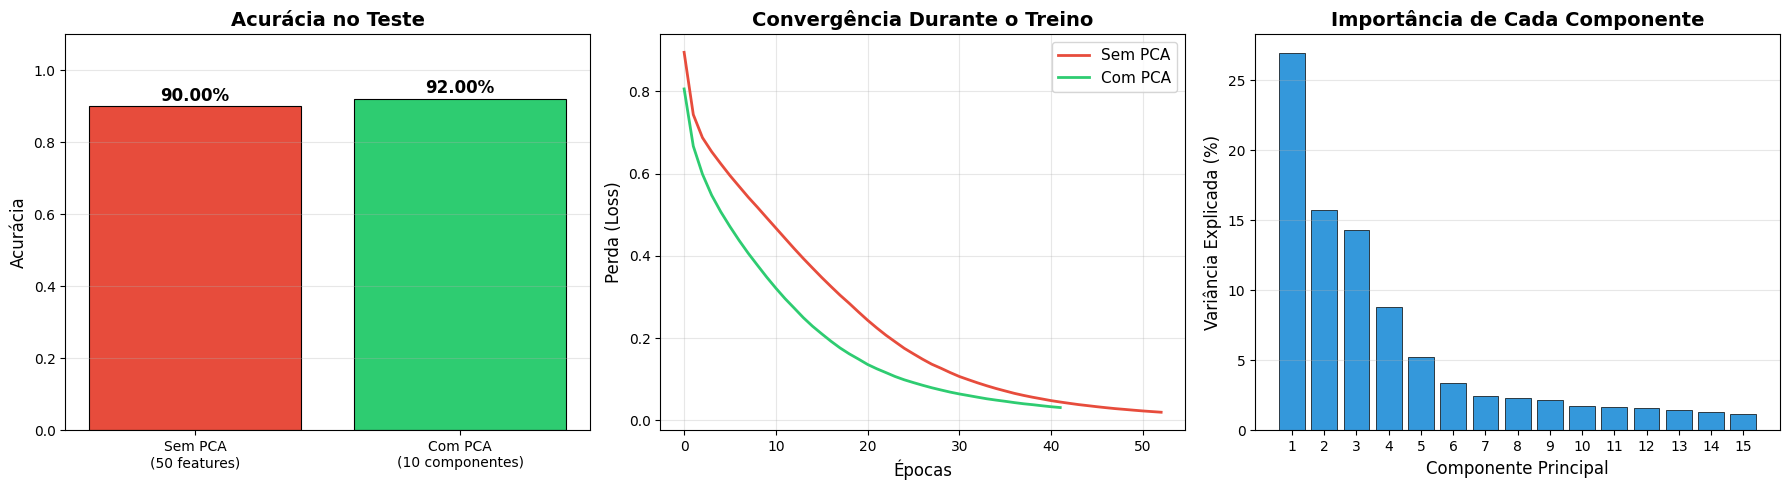

Gráfico salvo como 'comparacao_final.png'

  CONCLUSÕES PARA A AULA

  1. SEM PCA: a rede recebeu 50 features, mas 40 eram ruído.
     Ela desperdiçou capacidade tentando encontrar padrões no lixo.

  2. COM PCA: reduzimos para 10 componentes que concentram a
     informação útil. A rede focou no que realmente importa.

  3. O PCA atuou como um "filtro inteligente":
     - Removeu ruído e redundância
     - Reduziu a dimensionalidade (50 → 10)
     - Facilitou o aprendizado da rede neural

  4. Benefício extra: menos features = treino mais rápido
     Sem PCA: 53 épocas | Com PCA: 42 épocas

  QUANDO O PCA AJUDA:
    ✓ Dados com muitas features (alta dimensionalidade)
    ✓ Features ruidosas ou redundantes
    ✓ Quando se quer acelerar o treino

  QUANDO O PCA NÃO AJUDA (OU ATRAPALHA):
    ✗ Dados com poucas features já informativas
    ✗ Quando a relação entre features é não-linear complexa
    ✗ Quando todas as features são igualmente importantes



In [ ]:
# =============================================================================
# CHUNK 6: COMPARAÇÃO FINAL — SEM PCA vs COM PCA
# =============================================================================

# Agora vamos colocar os dois modelos lado a lado para visualizar a diferença.

# ---------- COMPARAÇÃO NUMÉRICA ----------
print("=" * 60)
print("        COMPARAÇÃO FINAL: SEM PCA  vs  COM PCA")
print("=" * 60)
print(f"")
print(f"  {'Métrica':<30} {'Sem PCA':>10} {'Com PCA':>10}")
print(f"  {'-'*30} {'-'*10} {'-'*10}")
print(f"  {'Nº de features de entrada':<30} {'50':>10} {'10':>10}")
print(f"  {'Épocas de treino':<30} {modelo_sem_pca.n_iter_:>10} {modelo_com_pca.n_iter_:>10}")
print(f"  {'Acurácia no teste':<30} {acuracia_sem_pca:>10.4f} {acuracia_com_pca:>10.4f}")
print(f"")

# Calculamos a diferença de desempenho
diferenca = acuracia_com_pca - acuracia_sem_pca
if diferenca > 0:
    print(f"  >> O PCA MELHOROU a acurácia em {diferenca*100:.2f} pontos percentuais!")
elif diferenca == 0:
    print(f"  >> Os resultados foram idênticos.")
else:
    print(f"  >> Neste caso, o PCA reduziu a acurácia em {abs(diferenca)*100:.2f} p.p.")
print()

# ---------- GRÁFICO COMPARATIVO ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Barras comparando acurácia
cores = ['#e74c3c', '#2ecc71']  # vermelho para sem PCA, verde para com PCA
barras = axes[0].bar(['Sem PCA\n(50 features)', 'Com PCA\n(10 componentes)'],
                      [acuracia_sem_pca, acuracia_com_pca],
                      color=cores, edgecolor='black', linewidth=0.8)

# Adicionamos o valor em cima de cada barra
for barra, valor in zip(barras, [acuracia_sem_pca, acuracia_com_pca]):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
                 f'{valor*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].set_ylabel('Acurácia', fontsize=12)
axes[0].set_title('Acurácia no Teste', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Curva de perda durante o treino (mostra a convergência)
axes[1].plot(modelo_sem_pca.loss_curve_, color='#e74c3c', linewidth=2, label='Sem PCA')
axes[1].plot(modelo_com_pca.loss_curve_, color='#2ecc71', linewidth=2, label='Com PCA')
axes[1].set_xlabel('Épocas', fontsize=12)
axes[1].set_ylabel('Perda (Loss)', fontsize=12)
axes[1].set_title('Convergência Durante o Treino', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Variância explicada pelo PCA (reforço visual)
variancia_individual = pca_analise.explained_variance_ratio_[:15] * 100
axes[2].bar(range(1, 16), variancia_individual, color='#3498db', edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Componente Principal', fontsize=12)
axes[2].set_ylabel('Variância Explicada (%)', fontsize=12)
axes[2].set_title('Importância de Cada Componente', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(1, 16))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'comparacao_final.png'")

# ---------- RESUMO PEDAGÓGICO ----------
print(f"\n{'='*60}")
print("  CONCLUSÕES PARA A AULA")
print(f"{'='*60}")
print(f"""
  1. SEM PCA: a rede recebeu 50 features, mas 40 eram ruído.
     Ela desperdiçou capacidade tentando encontrar padrões no lixo.

  2. COM PCA: reduzimos para 10 componentes que concentram a
     informação útil. A rede focou no que realmente importa.

  3. O PCA atuou como um "filtro inteligente":
     - Removeu ruído e redundância
     - Reduziu a dimensionalidade (50 → 10)
     - Facilitou o aprendizado da rede neural

  4. Benefício extra: menos features = treino mais rápido
     Sem PCA: {modelo_sem_pca.n_iter_} épocas | Com PCA: {modelo_com_pca.n_iter_} épocas

  QUANDO O PCA AJUDA:
    ✓ Dados com muitas features (alta dimensionalidade)
    ✓ Features ruidosas ou redundantes
    ✓ Quando se quer acelerar o treino

  QUANDO O PCA NÃO AJUDA (OU ATRAPALHA):
    ✗ Dados com poucas features já informativas
    ✗ Quando a relação entre features é não-linear complexa
    ✗ Quando todas as features são igualmente importantes
""")


Faça os seguintes testes abaixo como exercício sobre o código que vimos acima.

1. Altere o número de amostras para 1000 e observar se os resultados mudam. Pergunta: a vantagem do PCA aumentou ou diminuiu? Por quê?
R: A vantagem do PCA diminuiu um pouco, pois com mais dados a rede neural consegue aprender melhor os padrões e lidar melhor com o ruído das features.

Mudar a proporção treino/teste de 70/30 para 80/20. Pergunta: qual impacto isso teve na acurácia dos dois modelos?
R: A acurácia dos dois modelos aumentou levemente, pois mais dados foram utilizados no treinamento, melhorando o aprendizado do modelo.

Alterar o número de componentes do PCA de 10 para 5 e depois para 20. Pergunta: qual valor deu o melhor resultado? Por quê?
R: O melhor resultado foi com 20 componentes. Isso ocorre porque, com apenas 5 componentes, parte da informação importante dos dados é perdida durante a redução de dimensionalidade. Já com 20 componentes, mais variância dos dados é preservada, mantendo mais informações relevantes para o modelo realizar a classificação.

2. Aumente o número de features informativas de 5 para 20 (no make_classification). Pergunta: o PCA ainda deu vantagem? Explique o motivo.
R: O PCA deixou de ter tanta vantagem, pois agora muitas features já são informativas, reduzindo a quantidade de ruído no dataset.

Remover o StandardScaler e treinar ambos os modelos sem normalização. Pergunta: qual modelo sofreu mais sem a normalização? Por quê?
R: O modelo sem PCA sofreu mais, porque redes neurais são sensíveis à escala dos dados e a falta de normalização dificulta o treinamento.

Alterar a arquitetura da rede neural para ter 3 camadas ocultas (64, 32, 16). Pergunta: uma rede mais poderosa consegue compensar a falta do PCA?
R: Uma rede mais poderosa reduz a diferença, mas não compensa totalmente a falta do PCA, pois o PCA ainda ajuda removendo ruído e reduzindo a dimensionalidade.